<div style="background-color:#7BAFD4;border-radius:18px;padding:22px 26px;margin-bottom:18px;">
<div style="font-family:Impact,'Arial Black',Arial,sans-serif;font-size:42px;font-weight:900;letter-spacing:2px;line-height:1;color:white;">GEOG 592</div>
<div style="font-family:Arial,Helvetica,sans-serif;font-size:22px;font-weight:700;color:#13294B;margin-top:8px;">GIS Programming</div>
<div style="font-family:Arial,Helvetica,sans-serif;font-size:16px;color:#13294B;margin-top:6px;">GeoPandas — GeoDataFrames and Geometry</div></div>

# From pandas DataFrames to spatial DataFrames

GeoPandas extends pandas by adding geometry and coordinate reference system information.

By the end of this module, you should be able to read spatial data, identify a GeoDataFrame, inspect geometry and CRS, recognize geometry types, use familiar pandas operations, and make a quick map.


## Why GeoPandas matters

A GIS dataset is more than a table. Each row can also contain a geometry.


In [139]:
# Run this only if geopandas is not installed.
# %pip install geopandas

In [140]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

## Read a spatial file

In [141]:
stops = gpd.read_file("chapel_hill_bus_stops.geojson")
# originally from https://gis-portal.townofchapelhill.org/server/rest/services/OpenData/Bus_Stops/FeatureServer/0/query?where=1%3D1&outFields=*&returnGeometry=true&outSR=4326&f=geojson
# https://gis-portal.townofchapelhill.org/server/rest/services/
# Useful API Code: 0/query?where=1%3D1&outFields=*&returnGeometry=true&outSR=4326&f=geojson

stops

,OBJECTID,STOP_ID,STOP_ID2,NAME,DIR,ON_,AT,LAT,LONG,A,...,CAN_INSTAL,TRASH_PROB,TRASH_RECO,NEWSPAPER,NEWSPAPER_,BICYCLE,BIKE_SPACE,BIKE_PROBL,BIKE_RECOM,geometry
0,1,3000,3000,Fountain Ridge Rd at Overland Dr,W,Fountain Ridg,Overland Dr,35.936758,-79.008190,0,...,0,0,0,0,0,0,0,0,0,POINT (-79.00819 35.93676)
1,2,3001,3001,Summerfield Crossing at Grist Mill,W,Summerfield C,Grist Mill,35.943652,-79.025334,0,...,0,0,0,0,0,0,0,0,0,POINT (-79.02533 35.94365)
2,3,3002,3002,Fountain Ridge Rd at Highview Dr,W,Fountain Ridg,Highview Dr,35.936563,-79.004050,0,...,0,0,0,0,0,0,0,0,0,POINT (-79.00405 35.93656)
3,4,3012,3012,Ephesus Church Rd at Sharon Rd,E,Ephesus Churc,Sharon Rd,35.931930,-79.005350,0,...,0,0,0,0,0,0,0,0,0,POINT (-79.00535 35.93193)
4,5,3013,3013,Raleigh Rd at Best Western,E,Raleigh Rd,Aurora/Best,35.906650,-79.019990,0,...,0,0,0,0,0,0,0,0,0,POINT (-79.01999 35.90665)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
591,418,3484,3484,W Franklin St at Ham's,W,W Franklin St,Ham's,35.911370,-79.060590,0,...,0,0,0,0,0,1,4,0,0,POINT (-79.06043 35.91145)
592,406,3471,3471,W Franklin St at Kenan St,E,W Franklin St,Abandoned B,35.911380,-79.060140,0,...,0,0,0,0,0,0,0,0,0,POINT (-79.06007 35.91138)
593,364,3423,3423,W Franklin St at University Baptist,E,W Franklin St,University,35.912700,-79.056750,0,...,0,0,0,0,0,0,0,0,0,POINT (-79.05655 35.91275)
594,363,3422,3422,W Franklin St at Caribou Coffee,W,W Franklin St,Caribou Cof,35.912970,-79.056460,0,...,0,0,0,0,0,1,3,0,0,POINT (-79.05651 35.91297)


In [142]:
type(stops)

geopandas.geodataframe.GeoDataFrame

## Familiar pandas operations still work

In [143]:
stops.head()

,OBJECTID,STOP_ID,STOP_ID2,NAME,DIR,ON_,AT,LAT,LONG,A,...,CAN_INSTAL,TRASH_PROB,TRASH_RECO,NEWSPAPER,NEWSPAPER_,BICYCLE,BIKE_SPACE,BIKE_PROBL,BIKE_RECOM,geometry
0,1,3000,3000,Fountain Ridge Rd at Overland Dr,W,Fountain Ridg,Overland Dr,35.936758,-79.008190,0,...,0,0,0,0,0,0,0,0,0,POINT (-79.00819 35.93676)
1,2,3001,3001,Summerfield Crossing at Grist Mill,W,Summerfield C,Grist Mill,35.943652,-79.025334,0,...,0,0,0,0,0,0,0,0,0,POINT (-79.02533 35.94365)
2,3,3002,3002,Fountain Ridge Rd at Highview Dr,W,Fountain Ridg,Highview Dr,35.936563,-79.004050,0,...,0,0,0,0,0,0,0,0,0,POINT (-79.00405 35.93656)
3,4,3012,3012,Ephesus Church Rd at Sharon Rd,E,Ephesus Churc,Sharon Rd,35.931930,-79.005350,0,...,0,0,0,0,0,0,0,0,0,POINT (-79.00535 35.93193)
4,5,3013,3013,Raleigh Rd at Best Western,E,Raleigh Rd,Aurora/Best,35.906650,-79.019990,0,...,0,0,0,0,0,0,0,0,0,POINT (-79.01999 35.90665)


In [144]:
stops.shape

(596, 138)

In [145]:
stops.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [146]:
stops.columns

Index(['OBJECTID', 'STOP_ID', 'STOP_ID2', 'NAME', 'DIR', 'ON_', 'AT', 'LAT',
       'LONG', 'A',
       ...
       'CAN_INSTAL', 'TRASH_PROB', 'TRASH_RECO', 'NEWSPAPER', 'NEWSPAPER_',
       'BICYCLE', 'BIKE_SPACE', 'BIKE_PROBL', 'BIKE_RECOM', 'geometry'],
      dtype='object', length=138)

In [147]:
print(stops[["NAME","geometry"]])
print(type(stops[["NAME","geometry"]]))

                                    NAME                    geometry
0       Fountain Ridge Rd at Overland Dr  POINT (-79.00819 35.93676)
1     Summerfield Crossing at Grist Mill  POINT (-79.02533 35.94365)
2       Fountain Ridge Rd at Highview Dr  POINT (-79.00405 35.93656)
3         Ephesus Church Rd at Sharon Rd  POINT (-79.00535 35.93193)
4             Raleigh Rd at Best Western  POINT (-79.01999 35.90665)
..                                   ...                         ...
591               W Franklin St at Ham's  POINT (-79.06043 35.91145)
592            W Franklin St at Kenan St  POINT (-79.06007 35.91138)
593  W Franklin St at University Baptist  POINT (-79.05655 35.91275)
594      W Franklin St at Caribou Coffee  POINT (-79.05651 35.91297)
595     E Franklin St at Varsity Theatre   POINT (-79.05488 35.9136)

[596 rows x 2 columns]
<class 'geopandas.geodataframe.GeoDataFrame'>


## The geometry column

In [148]:
print(stops.geometry.head())
print(type(stops.geometry))

0    POINT (-79.00819 35.93676)
1    POINT (-79.02533 35.94365)
2    POINT (-79.00405 35.93656)
3    POINT (-79.00535 35.93193)
4    POINT (-79.01999 35.90665)
Name: geometry, dtype: geometry
<class 'geopandas.geoseries.GeoSeries'>


In [149]:
first_geometry = stops.geometry.iloc[0]
print(first_geometry)
print(type(first_geometry))

POINT (-79.00819000053941 35.93675799986392)
<class 'shapely.geometry.point.Point'>


Remember what you know about objects and dot notation:

- `stops` is a GeoDataFrame object
- `stops.geometry` is an attribute
- `stops.head()` is a method
- each individual geometry is also an object


## Geometry types

In [150]:
stops.geom_type

0      Point
1      Point
2      Point
3      Point
4      Point
       ...  
591    Point
592    Point
593    Point
594    Point
595    Point
Length: 596, dtype: object

In [151]:
urban_area = gpd.read_file("urban_area.geojson")
## from https://gis-portal.townofchapelhill.org/server/rest/services/OpenData/UrbanServiceBoundary/FeatureServer/0/query?where=1%3D1&outFields=*&returnGeometry=true&outSR=4326&f=geojson
print(urban_area.geom_type)
print(urban_area.crs)
urban_area

0    Polygon
dtype: object
EPSG:4326


,OBJECTID,URBANSER_,URBANSER_I,DATE,Shape__Area,Shape__Length,geometry
0,2,2,1,804470400000,7.150418e+08,158917.477493,"POLYGON ((-79.07451 35.87469, -79.07175 35.874..."


## Quick plotting

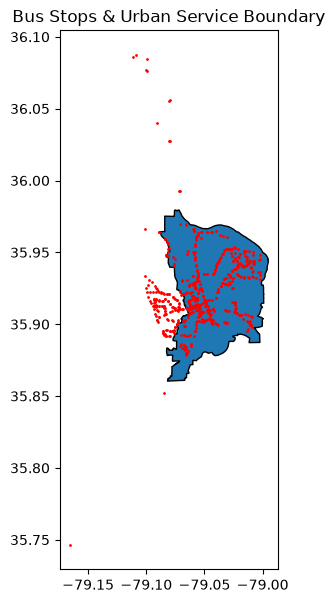

In [152]:
fig, ax = plt.subplots(figsize=(7,7))
urban_area.plot(ax=ax, edgecolor="black")
stops.plot(ax=ax, markersize=1, c="red")
ax.set_title("Bus Stops & Urban Service Boundary")
plt.show()

The order that you call the layer will have an effect on how it is displayed. 
Notice the difference below when we call the points before the polygon.

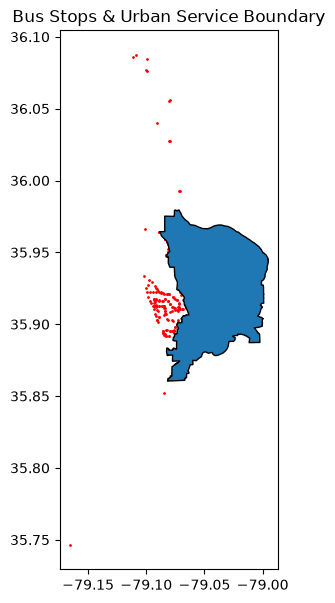

In [153]:
fig, ax = plt.subplots(figsize=(7,7))
stops.plot(ax=ax, markersize=1, c="red")
urban_area.plot(ax=ax, edgecolor="black")
ax.set_title("Bus Stops & Urban Service Boundary")
plt.show()

## Attribute filtering still works

In [154]:
list(stops.columns) ## to see all the columns 

['OBJECTID',
 'STOP_ID',
 'STOP_ID2',
 'NAME',
 'DIR',
 'ON_',
 'AT',
 'LAT',
 'LONG',
 'A',
 'CCX',
 'CL',
 'CM',
 'CPX',
 'CW',
 'D',
 'DX',
 'F',
 'FCX',
 'G',
 'HS',
 'HU',
 'HX',
 'J',
 'JFX',
 'N',
 'NS',
 'NU',
 'PX',
 'RU',
 'S',
 'T',
 'U',
 'V',
 'CMW_SAT',
 'SAT_CM',
 'SAT_CW',
 'DM_SAT',
 'FG_SAT',
 'JN_SAT',
 'NU_WKND',
 'T_SAT',
 'SFR_G',
 'SFR_J',
 'SFR_T',
 'BOARDINGS',
 'ALIGHTING',
 'UPGRADE',
 'SIGN',
 'SHARED',
 'LARGE_SIGN',
 'SMALL_SIGN',
 'SINGLE_POL',
 'SHARED_POL',
 'TELEPHONE_',
 'SIGN_ON_SH',
 'SIGN_ON_BU',
 'SIGN_HEIGH',
 'SIGN_CONDI',
 'SIGN_PROBL',
 'N8_5X11_SC',
 'N6_5X24_SC',
 'LARGE_SQUA',
 'SCHEDULE_M',
 'SCHEDULE_H',
 'NEAR_ADDRE',
 'PROPERTY_U',
 'LANDING_PA',
 'PAD_LOCATI',
 'PAD_MATERI',
 'PAD_PROBLE',
 'ADA_ACCESI',
 'MINABLE_AC',
 'NOT_ACCESS',
 'WHEELCHAIR',
 'SIDEWALK_W',
 'SIDEWALK_C',
 'SIDEWALK_2',
 'SIDEWALK_P',
 'MIDBLOCK_C',
 'INTERSECTI',
 'DISTANCE_F',
 'CURB_CUTS_',
 'CURB_CUTS2',
 'CROSSWALK',
 'CROSSING_S',
 'AUDIBLE_CR',
 'TACTILE_W

In [155]:

stops["CL"].value_counts() # look at the column containing info about the "CL" route

CL
0    520
1     76
Name: count, dtype: int64

In [156]:
#1 means that it has a stop and #0 means it does not
CL_stops = stops[stops["CL"] == 1].copy() ## selecting places where CL stops 
CL_stops

,OBJECTID,STOP_ID,STOP_ID2,NAME,DIR,ON_,AT,LAT,LONG,A,...,CAN_INSTAL,TRASH_PROB,TRASH_RECO,NEWSPAPER,NEWSPAPER_,BICYCLE,BIKE_SPACE,BIKE_PROBL,BIKE_RECOM,geometry
1,2,3001,3001,Summerfield Crossing at Grist Mill,W,Summerfield C,Grist Mill,35.943652,-79.025334,0,...,0,0,0,0,0,0,0,0,0,POINT (-79.02533 35.94365)
80,82,3101,3101,Legion Rd at Britthaven Shelter,E,Legion Rd,Britthaven,35.939620,-79.016700,0,...,0,0,0,0,0,0,0,0,0,POINT (-79.0167 35.93962)
82,84,3103,3103,Legion Rd at Wooded Area (#1719),W,Legion Rd,Wooded Area,35.940400,-79.015720,0,...,0,0,0,0,0,0,0,0,0,POINT (-79.01572 35.9404)
83,85,3104,3104,Legion Rd at Forsyth Dr,E,Legion Rd,Forsyth Dr,35.941526,-79.013592,0,...,0,0,0,0,0,0,0,0,0,POINT (-79.01359 35.94153)
89,91,3110,3110,Europa Dr at Hotel,W,Europa Dr,Hotel,35.941009,-79.018040,0,...,0,0,0,0,0,0,0,0,0,POINT (-79.01804 35.94101)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
399,404,3469,3469,Summerfield Crossing at Mossbark Ln,E,Summerfield C,Mossbark Ln,35.943781,-79.022083,0,...,0,0,0,0,0,0,0,0,0,POINT (-79.02208 35.94378)
470,480,3555,3555,Old Durham Rd at Cooper St,E,Old Durham Rd,Cooper St,35.944162,-79.008400,0,...,0,0,0,0,0,0,0,0,0,POINT (-79.0084 35.94416)
502,512,3593,3593,Legion Rd at #1718,E,Legion Rd,#1718,35.940490,-79.015420,0,...,0,0,0,0,0,0,0,0,0,POINT (-79.01542 35.94049)
577,587,3699,3699,Dobbins Dr. at Erwin,S,Dobbins,Erwin,35.942886,-79.019120,0,...,0,0,0,0,0,0,0,0,0,POINT (-79.01912 35.94289)


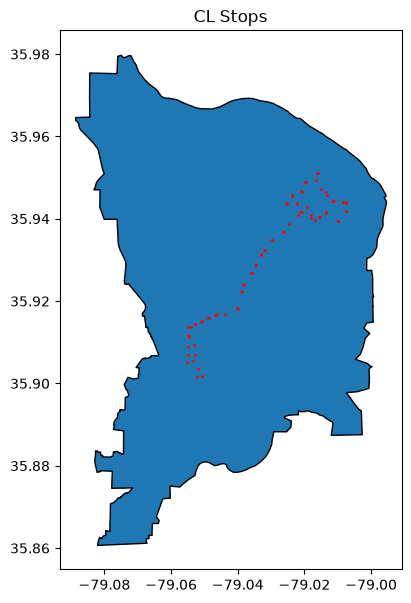

In [157]:
fig, ax = plt.subplots(figsize=(7,7))
urban_area.plot(ax=ax, edgecolor="black")
CL_stops.plot(ax=ax, markersize=1, c="red")
ax.set_title("CL Stops")
plt.show()

## Practice

Using another Chapel Hill geoJSON:

- download two geoJSONs from the Chapel Hill Server (not Stops, not the Boundary)
- inspect the type, shape, and columns
- select the name and geometry columns
- inspect the first geometry
- determine geometry types
- inspect the CRS
- filter the data
- make a copy of the result
- plot the selected features
- publish your work by uploading your JN to your GitHub (week06)


**Practice 1: Fire Stations**

In [158]:
fire_stations = gpd.read_file("fire_stations.geojson")
type(fire_stations)


geopandas.geodataframe.GeoDataFrame

In [159]:
fire_stations.shape

(5, 5)

In [160]:
fire_stations.columns

Index(['OBJECTID', 'NAME', 'TYPE', 'GlobalID', 'geometry'], dtype='object')

In [161]:
fire_stations[["NAME", "geometry"]]

,NAME,geometry
0,FIRE STATION 1,POINT (-79.05724 35.91606)
1,FIRE STATION 4,POINT (-79.05868 35.9639)
2,FIRE STATION 3,POINT (-79.03 35.93505)
3,FIRE STATION 2,POINT (-79.0234 35.90696)
4,FIRE STATION 5,POINT (-79.06004 35.88536)


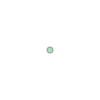

In [162]:
fire_stations.geometry.iloc[0]

In [163]:
fire_stations.geom_type

0    Point
1    Point
2    Point
3    Point
4    Point
dtype: object

In [164]:
fire_stations.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [165]:
selected_fire = fire_stations[fire_stations["NAME"] == fire_stations["NAME"].iloc[0]].copy()

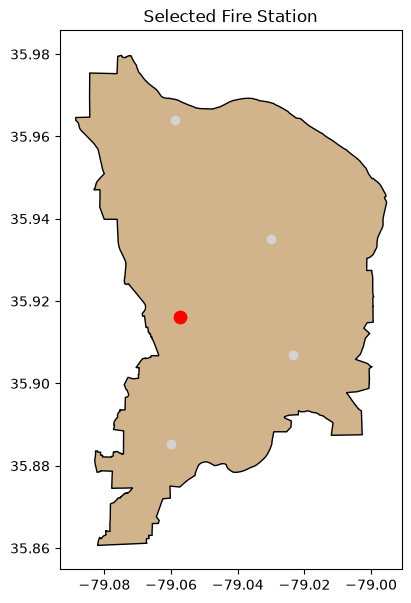

In [166]:
fig, ax = plt.subplots(figsize=(7, 7))
urban_area.plot(ax=ax, color="tan", edgecolor="black") #for visibility
fire_stations.plot(ax=ax, color="lightgray")
selected_fire.plot(ax=ax, color="red", markersize=80)
ax.set_title("Selected Fire Station")
plt.show()

**Practice 2: Neighborhoods**

In [167]:
neighborhoods = gpd.read_file("neighborhoods.geojson")
type(neighborhoods)

geopandas.geodataframe.GeoDataFrame

In [168]:
neighborhoods.shape

(246, 27)

In [169]:
neighborhoods.columns

Index(['OBJECTID', 'CONTACTDATE', 'ORG_NAME', 'ORG_TYPE', 'ORG_TYPE_OTHER',
       'NEIGHBORHOOD', 'PRIM_FNAME', 'PRIM_LNAME', 'PRIM_ADDRESS', 'PRIM_CITY',
       'PRIM_STATE', 'PRIM_ZIP_CODE', 'PRIM_PHONE', 'PRIM_EMAIL',
       'PRIM_WEBSITE', 'ALT_FNAME', 'ALT_LNAME', 'ALT_ST_ADDRESS', 'ALT_CITY',
       'ALT_STATE', 'ALT_ZIP_CODE', 'ALT_PHONE', 'ALT_EMAIL', 'ALT_WEB_SITE',
       'Shape__Area', 'Shape__Length', 'geometry'],
      dtype='object')

In [170]:
neighborhoods[["ORG_NAME", "geometry"]]

,ORG_NAME,geometry
0,None,"POLYGON ((-79.05768 35.91257, -79.0576 35.9126..."
1,None,"POLYGON ((-79.02245 35.90752, -79.02285 35.907..."
2,None,"MULTIPOLYGON (((-79.01176 35.93883, -79.01149 ..."
3,None,"MULTIPOLYGON (((-79.04471 35.94784, -79.04471 ..."
4,None,"POLYGON ((-79.0538 35.94511, -79.05411 35.9451..."
...,...,...
241,None,"MULTIPOLYGON (((-79.02119 35.92044, -79.0212 3..."
242,None,"MULTIPOLYGON (((-79.07752 35.87465, -79.07645 ..."
243,None,"POLYGON ((-79.06996 35.95164, -79.07058 35.951..."
244,None,"POLYGON ((-79.05784 35.91221, -79.05788 35.912..."


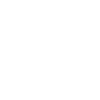

In [171]:
neighborhoods.geometry.iloc[0]

In [172]:
neighborhoods.geom_type

0           Polygon
1           Polygon
2      MultiPolygon
3      MultiPolygon
4           Polygon
           ...     
241    MultiPolygon
242    MultiPolygon
243         Polygon
244         Polygon
245         Polygon
Length: 246, dtype: object

In [173]:
neighborhoods.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [174]:
selected_neighborhoods = neighborhoods.iloc[:3].copy()

In [175]:
print(len(selected_neighborhoods))
print(neighborhoods["ORG_TYPE"].value_counts())

3
ORG_TYPE
Other    1
Name: count, dtype: int64


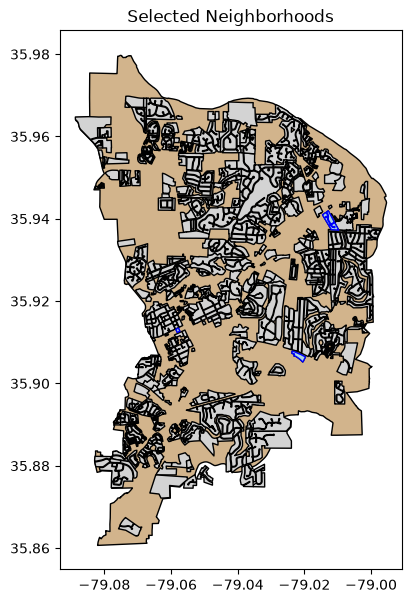

In [176]:
fig, ax = plt.subplots(figsize=(7, 7))
urban_area.plot(ax=ax, color="tan", edgecolor="black") #for easier visibility
neighborhoods.plot(ax=ax, color="lightgray", edgecolor="black")
selected_neighborhoods.plot(ax=ax, color="lightblue", edgecolor="blue")
ax.set_title("Selected Neighborhoods")
plt.show()

## What to remember

```python
gpd.read_file(...)
gdf.head()
gdf.shape
gdf.geometry
gdf.geom_type
gdf.crs
gdf.plot()
```

The main idea is that GeoPandas keeps the table structure of pandas and adds geometry.
